# 01 - Data quality audit

**Project:** do ARIMA, SARIMA and XGBoost beat a random walk when forecasting daily exchange rates?

This notebook comes before any chart and any model. Its job is to establish what the data actually is,
because three of the findings below change the design of the rest of the project, and two of them
contradict the brief that supplied the file.

The rule followed throughout: **a defect is investigated, not accepted.** Where a cleaning decision is
taken, the reason is written next to it, and where the source and the data disagree, the data wins and
the disagreement is recorded.

| # | Finding | Consequence |
|---|---|---|
| 1 | The file uses the string `ND` for non-trading days | Both rate columns arrive as text, not numbers |
| 2 | The brief states the quote direction backwards | Columns renamed to carry the true direction |
| 3 | The date index is a complete business-day range, with nothing missing | A frequency can be declared, which the models need |
| 4 | The CNY series is not one series, it is four policy regimes | Decides the train/test split of the whole project |
| 5 | The two currencies share a holiday calendar that belongs to neither of them | Explains finding 1 and dates the source |

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))

from src.data import RAW_FILE, SOURCE_COLUMNS, load_clean, load_raw, save_processed
from src.plots import save, use_style
import matplotlib.pyplot as plt

use_style()
pd.set_option("display.width", 120)
print(f"source file: {RAW_FILE.name}")

source file: Foreign_Exchange_Rates.csv


## 1. Load the file exactly as it was given

No `parse_dates`, no `na_values`, no dtype hints. Everything is read as text, so that the audit counts the
defects instead of being handed a frame in which pandas has already made the decisions.

In [2]:
raw = load_raw()
print(f"shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
print()
print(raw.dtypes.to_string())
raw.head()

shape: 5,217 rows x 3 columns

DATE                                str
SINGAPORE - SINGAPORE DOLLAR/US$    str
CHINA - YUAN/US$                    str


,DATE,SINGAPORE - SINGAPORE DOLLAR/US$,CHINA - YUAN/US$
0,2000-01-03,1.6563,8.2798
1,2000-01-04,1.6535,8.2799
2,2000-01-05,1.656,8.2798
3,2000-01-06,1.6655,8.2797
4,2000-01-07,1.6625,8.2794


Three columns, 5,217 rows, and **every column is `object`**. For a file whose entire content is a date and
two exchange rates, that is the first thing worth explaining rather than fixing.

In [3]:
# What is in the rate columns that is not a number?
rate_columns = list(SOURCE_COLUMNS.keys())
for column in rate_columns:
    values = raw[column]
    non_numeric = values[pd.to_numeric(values, errors="coerce").isna()]
    print(f"{column}")
    print(f"    non-numeric entries: {len(non_numeric):,}  distinct: {non_numeric.unique().tolist()}")

SINGAPORE - SINGAPORE DOLLAR/US$
    non-numeric entries: 198  distinct: ['ND']
CHINA - YUAN/US$
    non-numeric entries: 197  distinct: ['ND']


## Finding 1 - `ND` is the missing-value marker, and it is why the columns are text

198 rows in the Singapore column and 197 in the Chinese column hold the literal string `ND`. One
non-numeric value in a column of 5,217 is enough to make the whole column text, which is how a file that
looks clean in a spreadsheet arrives broken in pandas.

This matters more than a normal missing value would. `pd.to_numeric(..., errors="coerce")` turns them into
NaN silently, and a NaN in a price series is not a gap in a survey: it is a day on which no price was
published. What is done about it is a decision, and the three available options are not equivalent.

In [4]:
nd_mask = raw[rate_columns].eq("ND")
print(f"rows where at least one column is ND : {nd_mask.any(axis=1).sum()}")
print(f"rows where BOTH columns are ND      : {nd_mask.all(axis=1).sum()}")
print(f"Singapore only                      : {(nd_mask.iloc[:, 0] & ~nd_mask.iloc[:, 1]).sum()}")
print(f"China only                          : {(~nd_mask.iloc[:, 0] & nd_mask.iloc[:, 1]).sum()}")

rows where at least one column is ND : 198
rows where BOTH columns are ND      : 197
Singapore only                      : 1
China only                          : 0


Almost every `ND` day is missing in **both** currencies at once. A gap that lands on both series on the
same day is not two markets independently taking a holiday, it is one publisher not publishing. That is a
clue about where the file comes from, and the next cell follows it.

In [5]:
nd_dates = pd.to_datetime(raw.loc[nd_mask.iloc[:, 0], "DATE"])
by_calendar_day = nd_dates.dt.strftime("%m-%d").value_counts()
print("Most frequent missing calendar days, over 20 years:")
print(by_calendar_day.head(10).to_string())

Most frequent missing calendar days, over 20 years:
DATE
07-04    16
12-25    15
01-01    14
11-11    13
05-28     4
11-12     4
01-21     4
02-18     4
12-26     4
02-20     4


## Finding 5 - the holiday calendar is American, and it belongs to neither currency

4 July appears 16 times, 25 December 15, 1 January 14, 11 November 13. Those are **United States federal
holidays**: Independence Day, Christmas, New Year and Veterans Day. Singapore and Shanghai were open on
most of them, and Chinese New Year, which would close the Shanghai market for a week every year, does not
appear in the list at all.

So the file is not a record of when these currencies traded. It is a record of **when a US institution
published a rate**, which is consistent with the Federal Reserve H.10 series. That is the correct reading
of the gaps and it decides how to fill them:

- **Drop the rows.** Rejected. It would delete 198 valid business days from the series and break the even
  spacing that the lag features and the seasonal terms depend on.
- **Interpolate.** Rejected, and this is the one that would quietly damage the project. Interpolation
  between the day before and the day after invents a price using a value from the future. In a repository
  whose whole claim is that the backtest contains no look-ahead, a linear interpolation in the cleaning
  step would be leakage introduced before the first model is even fitted.
- **Forward-fill.** Chosen. On a day when nothing was published, the last published rate is the most
  recent information anybody actually had. It uses only the past, which is the rule the rest of the
  project is held to.

In [6]:
with_nan = load_clean(fill_holidays=False)
clean = load_clean()

print(f"NaN after parsing        : {with_nan.isna().sum().to_dict()}")
print(f"NaN after forward-fill   : {clean.isna().sum().to_dict()}")
print(f"rows before / after      : {len(with_nan):,} / {len(clean):,}   (nothing dropped)")
print()

# What did the fill actually change? Show one real example rather than asserting it worked.
example = with_nan.index[with_nan["SGD_per_USD"].isna()][10]
window = slice(example - pd.Timedelta(days=4), example + pd.Timedelta(days=4))
pd.concat(
    [with_nan.loc[window].add_suffix("_raw"), clean.loc[window].add_suffix("_filled")], axis=1
).round(4)

NaN after parsing        : {'SGD_per_USD': 198, 'CNY_per_USD': 197}


NaN after forward-fill   : {'SGD_per_USD': 0, 'CNY_per_USD': 0}
rows before / after      : 5,217 / 5,217   (nothing dropped)



,SGD_per_USD_raw,CNY_per_USD_raw,SGD_per_USD_filled,CNY_per_USD_filled
date,,,,
2001-02-15,1.7435,8.2772,1.7435,8.2772
2001-02-16,1.7386,8.2770,1.7386,8.2770
2001-02-19,NaN,NaN,1.7386,8.2770
2001-02-20,1.7400,8.2767,1.7400,8.2767
2001-02-21,1.7445,8.2772,1.7445,8.2772
2001-02-22,1.7445,8.2769,1.7445,8.2769
2001-02-23,1.7448,8.2774,1.7448,8.2774


## Finding 2 - the brief states the quote direction backwards

The brief describes the Singapore column as *"the exchange rate of 1 Singapore Dollar (SGD) in US Dollars
(USD)"*. The column's first value is **1.6563**. One Singapore dollar has never been worth 1.66 US
dollars; over this period it was worth about 0.60. The number is the other direction: **1.6563 Singapore
dollars per 1 US dollar**. The same applies to the Chinese column, where 8.28 is yuan per dollar.

This is small and it is not cosmetic. Every interpretation in the project flips on it: a **rising** line
means the local currency getting **weaker**, not stronger, and a forecast error of 0.004 is 0.004
Singapore dollars per dollar, not 0.004 US dollars. A conclusion written against the brief's wording would
be backwards in the sentence a reader actually remembers.

The fix is to put the direction in the column name, so the unit travels with the data and cannot be
misread downstream: `SGD_per_USD`, `CNY_per_USD`.

In [7]:
first_row = clean.iloc[0]
print(f"First observation, {clean.index[0].date()}")
print(f"    SGD_per_USD = {first_row['SGD_per_USD']:.4f}  ->  1 USD buys {first_row['SGD_per_USD']:.4f} SGD")
print(f"                                    ->  1 SGD buys {1 / first_row['SGD_per_USD']:.4f} USD")
print()
print(f"    CNY_per_USD = {first_row['CNY_per_USD']:.4f}  ->  1 USD buys {first_row['CNY_per_USD']:.4f} CNY")
print(f"                                    ->  1 CNY buys {1 / first_row['CNY_per_USD']:.4f} USD")
print()
print("The brief's description would require the second line of each pair. The file holds the first.")

First observation, 2000-01-03


    SGD_per_USD = 1.6563  ->  1 USD buys 1.6563 SGD
                                    ->  1 SGD buys 0.6038 USD

    CNY_per_USD = 8.2798  ->  1 USD buys 8.2798 CNY
                                    ->  1 CNY buys 0.1208 USD

The brief's description would require the second line of each pair. The file holds the first.


## Finding 3 - the date index is complete, which is rarer than it sounds

Before trusting any lag feature, the spacing of the index has to be checked. A lag of 5 rows is only "one
week ago" if no weekday is missing from the file.

In [8]:
dates = pd.to_datetime(raw["DATE"])
expected = pd.bdate_range(dates.min(), dates.max())

print(f"date range          : {dates.min().date()} to {dates.max().date()}")
print(f"duplicate dates     : {dates.duplicated().sum()}")
print(f"sorted ascending    : {dates.is_monotonic_increasing}")
print(f"weekend rows        : {(dates.dt.dayofweek >= 5).sum()}")
print(f"business days expected in range : {len(expected):,}")
print(f"business days present in file   : {len(dates):,}")
print(f"weekdays missing                : {len(expected.difference(pd.DatetimeIndex(dates)))}")
print()
print(f"declared index frequency after cleaning: {clean.index.freq}")

date range          : 2000-01-03 to 2019-12-31
duplicate dates     : 0
sorted ascending    : True
weekend rows        : 0
business days expected in range : 5,217
business days present in file   : 5,217
weekdays missing                : 0

declared index frequency after cleaning: <BusinessDay>


Not one weekday is missing across twenty years. The file covers every Monday to Friday from 2000-01-03 to
2019-12-31 and marks the non-trading ones with `ND` rather than omitting them, which is what makes finding
1 recoverable at all.

The practical payoff: the index can be declared as business-day frequency. Without that, `statsmodels`
falls back to integer positions, warns on every fit, and cannot date its own forecasts.

In [9]:
# Remaining routine checks, all clean. Reported rather than skipped, because "we looked" is part of an
# audit and a reader cannot tell the difference between a check that passed and a check never run.
checks = {
    "non-positive rates": int((clean <= 0).sum().sum()),
    "duplicate dates": int(clean.index.duplicated().sum()),
    "rows with any NaN": int(clean.isna().any(axis=1).sum()),
    "SGD outside 1.0 - 2.0": int(((clean["SGD_per_USD"] < 1.0) | (clean["SGD_per_USD"] > 2.0)).sum()),
    "CNY outside 5.0 - 9.0": int(((clean["CNY_per_USD"] < 5.0) | (clean["CNY_per_USD"] > 9.0)).sum()),
}
for label, count in checks.items():
    print(f"{label:<26}: {count}")
print()
clean.describe().round(4)

non-positive rates        : 0
duplicate dates           : 0
rows with any NaN         : 0
SGD outside 1.0 - 2.0     : 0
CNY outside 5.0 - 9.0     : 0



,SGD_per_USD,CNY_per_USD
count,5217.0000,5217.0000
mean,1.4802,7.1993
std,0.1888,0.8199
min,1.2007,6.0402
25%,1.3426,6.4758
50%,1.4084,6.8597
75%,1.6787,8.2765
max,1.8540,8.2800


## Finding 4 - the Chinese series is four policy regimes, not one series

This is the finding that changes the design of the project.

An exchange rate is only a market price when it is allowed to be one. Counting how many *distinct* values
each series takes per year is a direct measure of that, and it needs no domain knowledge to read: a
floating currency prints a new number most days, a pegged one repeats itself.

In [10]:
returns = np.log(clean).diff()

regime_table = pd.DataFrame(
    {
        "trading_days": clean["CNY_per_USD"].resample("YE").size(),
        "distinct_values": clean["CNY_per_USD"].resample("YE").nunique(),
        "yearly_range": (clean["CNY_per_USD"].resample("YE").max()
                         - clean["CNY_per_USD"].resample("YE").min()),
        "ann_vol_pct": returns["CNY_per_USD"].resample("YE").std() * np.sqrt(252) * 100,
        "sgd_ann_vol_pct": returns["SGD_per_USD"].resample("YE").std() * np.sqrt(252) * 100,
    }
)
regime_table.index = regime_table.index.year
regime_table.round(3)

,trading_days,distinct_values,yearly_range,ann_vol_pct,sgd_ann_vol_pct
date,,,,,
2000,260,31,0.003,0.071,3.438
2001,261,25,0.011,0.196,4.330
2002,261,15,0.010,0.153,4.307
2003,261,15,0.003,0.117,4.314
2004,262,11,0.001,0.022,4.791
2005,260,91,0.206,2.002,4.463
2006,260,219,0.266,1.069,4.006
2007,261,218,0.518,1.765,3.720
2008,262,217,0.515,3.041,7.272


Read the `distinct_values` column down the page. In 2004 the yuan took **11 different values in 262
trading days** and moved a total of 0.001 across the entire year. In 2018 it took 224 values and moved
0.709. Annualised volatility runs from **0.02 percent to 4.70 percent**, a factor of over two hundred,
inside one column of one file.

Four regimes, and each of the breaks is a dated policy decision that shows up as one of the largest daily
moves in the series:

In [11]:
biggest = returns["CNY_per_USD"].abs().nlargest(5)
pd.DataFrame(
    {
        "log_return_pct": (returns["CNY_per_USD"].loc[biggest.index] * 100).round(3),
        "level_after": clean["CNY_per_USD"].loc[biggest.index].round(4),
    }
)

,log_return_pct,level_after
date,,
2005-07-22,-2.019,8.1111
2015-08-11,1.816,6.3232
2019-08-05,1.564,7.0481
2017-10-10,-1.242,6.5712
2018-12-03,-1.099,6.8798


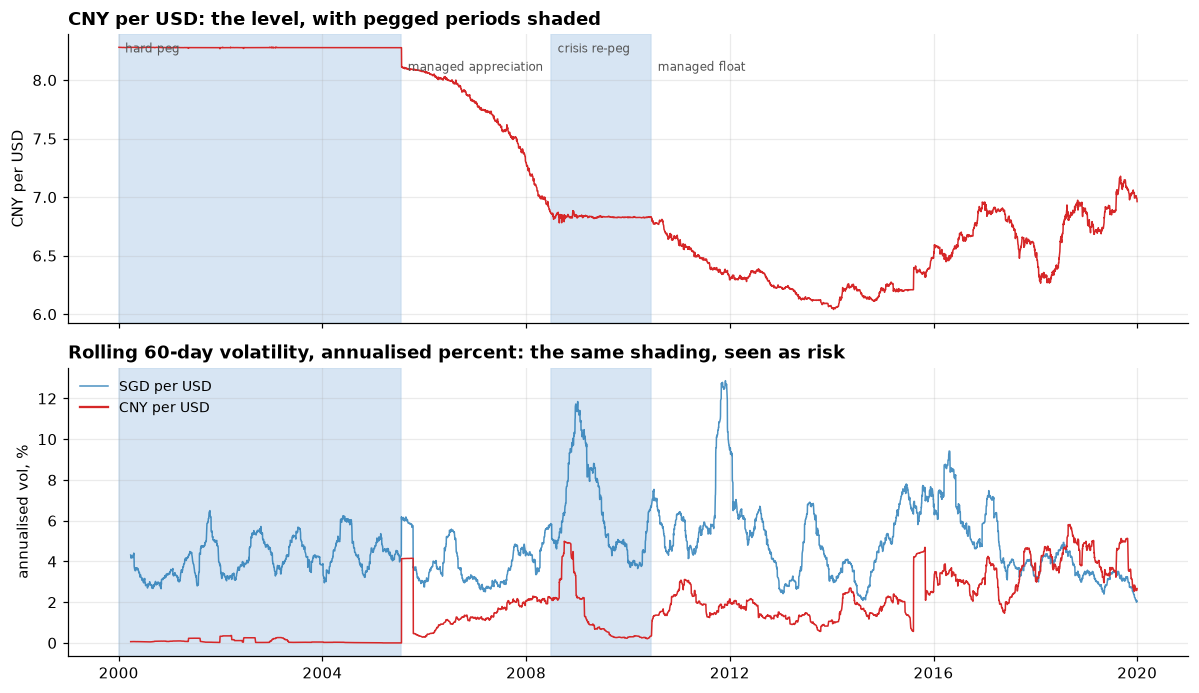

In [12]:
REGIMES = [
    ("2000-01-03", "2005-07-21", "hard peg", "#c6dbef"),
    ("2005-07-22", "2008-06-30", "managed appreciation", "#ffffff"),
    ("2008-07-01", "2010-06-18", "crisis re-peg", "#c6dbef"),
    ("2010-06-19", "2019-12-31", "managed float", "#ffffff"),
]

fig, axes = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True)

for start, end, label, shade in REGIMES:
    if shade != "#ffffff":
        for ax in axes:
            ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=shade, alpha=0.7, zorder=0)

axes[0].plot(clean.index, clean["CNY_per_USD"], color="#d62728", lw=1.0, zorder=3)
axes[0].set_title("CNY per USD: the level, with pegged periods shaded")
axes[0].set_ylabel("CNY per USD")

rolling_vol = returns["CNY_per_USD"].rolling(60).std() * np.sqrt(252) * 100
axes[1].plot(rolling_vol.index, rolling_vol, color="#d62728", lw=1.0, zorder=3)
axes[1].plot(
    (returns["SGD_per_USD"].rolling(60).std() * np.sqrt(252) * 100).index,
    returns["SGD_per_USD"].rolling(60).std() * np.sqrt(252) * 100,
    color="#1f77b4", lw=1.0, alpha=0.8, zorder=2, label="SGD per USD",
)
axes[1].plot([], [], color="#d62728", label="CNY per USD")
axes[1].set_title("Rolling 60-day volatility, annualised percent: the same shading, seen as risk")
axes[1].set_ylabel("annualised vol, %")
axes[1].legend(loc="upper left")

# Stagger the labels vertically: the two middle regimes are short enough that their names would
# otherwise overlap on the shared top line.
for row, (start, _, label, _) in enumerate(REGIMES):
    axes[0].annotate(label, xy=(pd.Timestamp(start), axes[0].get_ylim()[1]),
                     xytext=(4, -12 - 12 * (row % 2)), textcoords="offset points",
                     fontsize=8, color="#555555")

fig.tight_layout()
save(fig, "01_cny_policy_regimes")
plt.show()

The bottom panel is the version of this that matters for forecasting. Through the peg the yuan's
volatility is a flat line near zero, then it steps up twice. The Singapore dollar, on the same axis, is a
genuinely floating currency the whole way through.

**What follows for the project design.** A model trained across the peg is not learning how exchange rates
behave, it is learning that this number used to be constant. Any benchmark run over the full history would
report a spectacular result on the pegged years and tell us nothing about forecasting.

So the backtest is run on **2016 onward**, where both currencies float, and the whole pre-2016 history is
kept as the training window that the expanding walk-forward starts from. That is not a convenience split.
It is the only window in this file where the question the brief asks is a meaningful question for both
series.

In [13]:
TEST_START = "2016-01-01"
train_span = clean.loc[:TEST_START]
test_span = clean.loc[TEST_START:]

print(f"training history : {train_span.index.min().date()} to {train_span.index.max().date()}"
      f"  ({len(train_span):,} days)")
print(f"backtest window  : {test_span.index.min().date()} to {test_span.index.max().date()}"
      f"  ({len(test_span):,} days)")
print()
print("Annualised volatility in the backtest window, both currencies floating:")
print((np.log(test_span).diff().std() * np.sqrt(252) * 100).round(2).to_string())

training history : 2000-01-03 to 2016-01-01  (4,175 days)
backtest window  : 2016-01-01 to 2019-12-31  (1,043 days)

Annualised volatility in the backtest window, both currencies floating:
SGD_per_USD    4.71
CNY_per_USD    3.82


## Write the clean series out

One file, two float columns, a business-day index, no missing values, and column names that carry the
quote direction. Everything after this point loads it through `src.data.load_clean` rather than reading
the raw CSV again, so no notebook can quietly apply a different cleaning rule.

In [14]:
path = save_processed(clean, "fx_clean.csv")
print(f"wrote {path.relative_to(path.parents[2])}  ({len(clean):,} rows)")
clean.tail(3).round(4)

wrote data\processed\fx_clean.csv  (5,217 rows)


,SGD_per_USD,CNY_per_USD
date,,
2019-12-27,1.3520,6.9954
2019-12-30,1.3483,6.9864
2019-12-31,1.3446,6.9618


## Audit summary

| # | Finding | What was done |
|---|---|---|
| 1 | `ND` in 198 rows makes both rate columns text | Parsed as NaN, then forward-filled. Interpolation rejected as look-ahead, dropping rejected as breaking the spacing |
| 2 | The brief's quote direction is inverted | Columns renamed `SGD_per_USD` / `CNY_per_USD` so the unit cannot be misread |
| 3 | Every weekday present, no duplicates, no impossible values | Business-day frequency declared on the index |
| 4 | CNY spans four policy regimes, volatility varying 200-fold | Backtest restricted to 2016 onward, where both currencies float |
| 5 | The missing days are US federal holidays | Identifies the source as a US publication and justifies the forward fill |

Two of these contradict the document that supplied the data. Neither was found by running a profiling
tool over the file: finding 2 needed someone to know what a Singapore dollar is worth, and finding 4
needed someone to ask why a price column would repeat itself for a year.

Next: `02_eda_trend_seasonality_volatility.ipynb`, which answers the four questions the brief asks about
this data, and finds that the most obvious of them has an answer that is off by a factor of four.